In [11]:
import sys
sys.path.append('..')  # 让 Python 能找到上一级目录（即 energy_reconstruction）

from src import ParticleDataset, EdgeConvBlock, ParticleRegressor, train_model, evaluate_model


In [12]:
print(ParticleDataset)
print(ParticleRegressor)
print(train_model)


<class 'src.ParticleDataset.ParticleDataset'>
<module 'src.ParticleRegressor' from '/home/server/projects/energy_reconstruction/notebook/../src/ParticleRegressor.py'>
<function train_model at 0x7ec3591b9f30>


In [2]:
import uproot
import pandas as pd
import os

root_path = "/mnt/mydisk/WCDA_simulation/" # WCDA_simulation folder

file_path = []
for filename in os.listdir(root_path):
	full_path = os.path.join(root_path, filename)
	file_path.append(full_path)

# 打开第一个root文件，看看文件格式
file = uproot.open(file_path[6666])
print(f"================ {file_path[0]} 内容概览 ================")
# 1. 显示文件中的所有对象
print("\n文件中的对象列表:")
for key in file.keys():
    print(f"  - {key}")

# 2. 查看TTree的详细信息
for path, obj in file.items():
    if isinstance(obj, uproot.TTree):
        print(f"\n>>> 树: {path} <<<")
        print(f"总条目数: {obj.num_entries}")
        
        # 显示分支信息
        print("\n分支结构:")
        for branch_name in obj.keys():
            branch = obj[branch_name]
            print(f"  - {branch_name.ljust(30)} {str(branch.typename).ljust(20)}")
        
      #   # 显示前几行数据
      #   print("\n前3行数据示例:")
      #   print(obj.arrays(library="pd", entry_stop=3))

================ /mnt/mydisk/WCDA_simulation/Egr000007744_01_n0010_eventout.root 内容概览 ================

文件中的对象列表:
  - t_eventout_h;1
  - t_eventout;1

>>> 树: t_eventout_h;1 <<<
总条目数: 1

分支结构:
  - mtime                          std::string         
  - filename                       std::string         
  - infiles                        std::string         
  - texts                          std::string         

>>> 树: t_eventout;1 <<<
总条目数: 3779

分支结构:
  - n                              int32_t             
  - nfit0                          int32_t             
  - nfit                           int32_t             
  - nfitb                          int32_t             
  - vnfit                          int32_t[4]          
  - fitstat                        int32_t             
  - nrange                         int32_t             
  - nv                             int32_t             
  - vflag                          int32_t[]           
  - vidmc                          in

In [3]:
# 转换为 pandas DataFrame（前3条）
tree = file["t_eventout;1"]
df = tree.arrays(library="pd")
df.head(5)

,n,nfit0,nfit,nfitb,vnfit,fitstat,nrange,nv,vflag,vidmc,...,f5w,mc_weight,mc_pid,mc_energy,mc_theta,mc_phi,mc_xc,mc_yc,mc_dangle,mc_dcore
0,406,168,135,87,[25 11 16 35],0,223,223,"[-101072341, 101023069, 101022091, 101022113, ...","[2341, 3069, 2091, 2113, 2085, 2149, 2122, 234...",...,0.0,400.000000,1,47.714085,0.175695,4.414244,80.370889,-154.029746,0.221502,234.006968
1,278,63,41,21,[17 4 0 0],0,72,72,"[101023028, -101073065, 111121755, 111121697, ...","[3028, 3065, 1755, 1697, 1547, 1434, 1526, 309...",...,0.0,385.907135,1,279.356110,0.611763,4.901412,-4.876267,-87.929082,0.704629,46.100323
2,314,42,25,16,[3 6 7 0],0,74,74,"[-101071722, -101071499, -101071754, 101121518...","[1722, 1499, 1754, 1518, 1468, 2819, 1438, 151...",...,0.0,321.745667,1,17.331480,0.561470,5.316322,41.848032,-26.930076,0.437109,74.772003
3,371,131,112,48,[3 0 19 26],0,186,186,"[101022984, 111112635, 111112503, 111112393, 1...","[2984, 2635, 2503, 2393, 2767, 2349, 2239, 241...",...,0.0,370.290802,1,1171.677124,0.169711,1.367156,-15.888357,130.695605,0.006494,10.195373
4,214,24,8,6,[5 0 0 1],0,23,23,"[101020608, 111120362, 111020609, 111020906, 1...","[608, 362, 609, 906, 45, 851, 672, 492, 615, 7...",...,0.0,400.000000,1,77.719017,0.402139,4.951337,36.202278,129.656475,0.182934,207.206241


In [9]:
import sys
print(sys.executable)


/home/server/anaconda3/envs/py310/bin/python


📁 本次随机选取使用 100 个ROOT文件数据进行评估
GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.01 GB
  内存缓存: 4.47 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4


✅ Loaded 95958 events from 100 files
评估模型...
使用设备: cuda
⚙️ 检测到 DataParallel 模型，已移除 'module.' 前缀
✅ 成功加载模型权重: /home/server/projects/energy_reconstruction/best_model_150_500.pt

=== 模型评估结果 ===
能量分辨率 (resolution): 0.6397
能量偏差 (bias): -0.0307
✅ Resolution 图像已保存到: /home/server/projects/energy_reconstruction/fig/resolution_20251110_153411.png


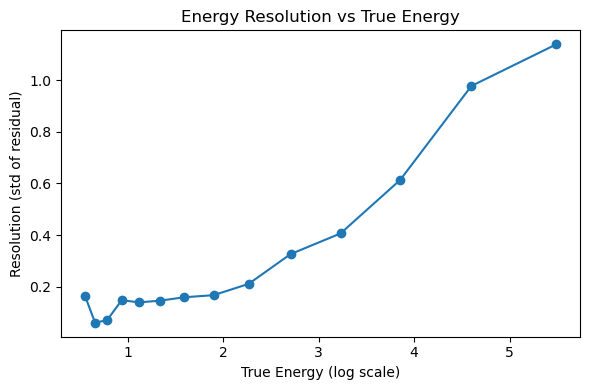

✅ LogE_pred vs logE_true 图像已保存到: /home/server/projects/energy_reconstruction/fig/pred_vs_true_20251110_153411.png


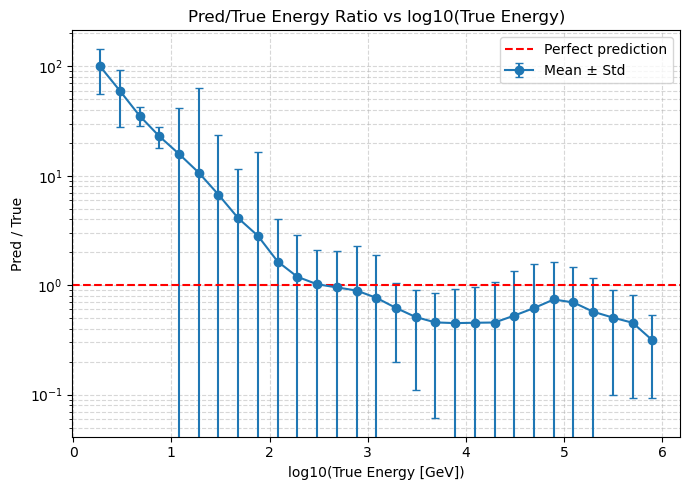

In [ ]:
import sys
import os
from torch.utils.data import Dataset, DataLoader
sys.path.append(os.path.abspath(".."))  # 添加上一级目录

from src import utils
from src.evaluate import evaluate_model
from src.Particledf_errorset import Particledf_errorset
from src.ParticleRegressor import ParticleNetRegressor
import random
# 主函数
def main():
    '''
    加载保存的model进行评估的主函数
     '''
   
	 # ======== 读取数据文件夹 ========
    root_path = "/home/server/mydisk/WCDA_split/nv_150_500/" # WCDA_simulation folder
    file_path = []
    for filename in os.listdir(root_path):
           full_path = os.path.join(root_path, filename)
           file_path.append(full_path)
    
	 # 随机提取100个进行评估
    test_files = file_path[-100:] # 500*20%
    print(f"📁 本次随机选取使用 {len(test_files)} 个ROOT文件数据进行评估")

	 # ======== 预处理条件 ========       
    processing_conditions = [
            {"name": "vx",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vy",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},  
            {"name": "vt",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vq",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0}
        ]
    branches = [d["name"] for d in processing_conditions] # 提取name列表，便于后续读取相关的值 ，输入特征
    target_branch = ["mc_energy"] # 定义一个标签列表， 预测目标是能量
    processing_conditions = [
        {k: v for k, v in d.items() if k != "name"} # 删除掉name字段，只保留预处理操作字段
        for d in processing_conditions
    ]
    
   #  # ======== 先检查GPU状态 ========
    utils.check_gpu_status()
   
    # 只构建test数据集
    batch_size = 256 
    test_df_errorset = Particledf_errorset(
        root_files=test_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # ======== 初始化模型 ========
    model = ParticleNetRegressor(
        input_dims=2,  # vq, vt 两个特征
        conv_params=[(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
        fc_params=[(256, 0.1), (128, 0.1)],
        use_fusion=True
    )
    
    # ======== 评估模型 ========
    print("评估模型...")
   #  model.load_state_dict(torch.load("best_model.pt")) #不需要重新train，直接evaluate
   #  model.eval()
    pred, energies = evaluate_model(model, test_loader, checkpoint_path="/home/server/projects/energy_reconstruction/best_model_150_500.pt")
    
    return pred, energies
   

if __name__ == "__main__":
    import numpy as np
    import matplotlib.pyplot as plt

    pred, true = main()  # log10(E)

    # ---- 分 bin 统计 pred/true ----
    bins = np.linspace(true.min(), true.max(), 30)  # logE 空间等宽分 bin
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    ratio_mean, ratio_std = [], []

    for i in range(len(bins) - 1):
        mask = (true >= bins[i]) & (true < bins[i + 1])
        if mask.sum() > 10:  # 至少有一定统计量
            ratio = np.power(10, pred[mask] - true[mask])  # pred/true = 10^(ΔlogE)
            ratio_mean.append(np.mean(ratio))
            ratio_std.append(np.std(ratio))
        else:
            ratio_mean.append(np.nan)
            ratio_std.append(np.nan)

    # ---- 绘图 ----
    plt.figure(figsize=(7,5))
    plt.errorbar(bin_centers, ratio_mean, yerr=ratio_std, fmt='o-', capsize=3, label='Mean ± Std')
    plt.axhline(1.0, color='r', linestyle='--', label='Perfect prediction')
    plt.xlabel('log10(True Energy [GeV])')
    plt.ylabel('Pred / True')
    plt.yscale('log')
    plt.title('Pred/True Energy Ratio vs log10(True Energy)')
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



log空间导致的分辨率在高能变差
resolution = std(logE_pred - logE_true)

低能：
虽然散点在 log–log 图上看似飘得很宽，但它的 logE 差其实在 ±0.1 – 0.2 左右；、
高能：结果就是 σ_logE 显著变大，表现为右图上高能端“分叉”的散点云。

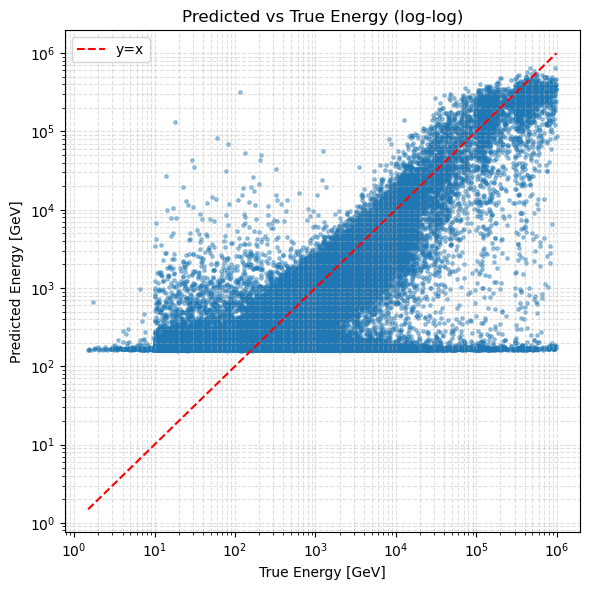

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

# 把 log10(E) 转换回线性能量
true_E = 10 ** true
pred_E = 10 ** pred

plt.scatter(true_E, pred_E, s=6, alpha=0.4)

mn = min(true_E.min(), pred_E.min())
mx = max(true_E.max(), pred_E.max())
plt.plot([mn, mx], [mn, mx], 'r--', label='y=x')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('True Energy [GeV]')
plt.ylabel('Predicted Energy [GeV]')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.title('Predicted vs True Energy (log-log)')
plt.tight_layout()
plt.show()


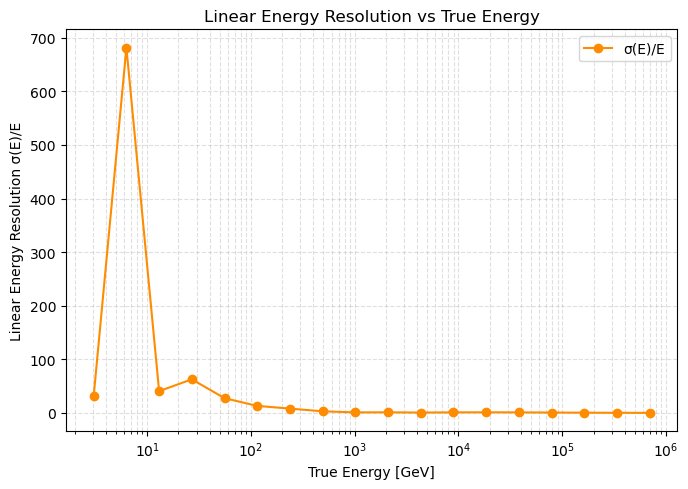

: 

In [ ]:
# 线性分辨率
import numpy as np
import matplotlib.pyplot as plt

# 假设 pred, true 都是 log10(E)
true_E = 10 ** true
pred_E = 10 ** pred

# --- 计算线性相对误差 (E_pred - E_true)/E_true ---
rel_error = (pred_E - true_E) / true_E

# --- 分能量 bin 统计标准差 (分辨率) ---
bins = np.logspace(np.log10(true_E.min()), np.log10(true_E.max()), 20)
bin_centers = np.sqrt(bins[:-1] * bins[1:])
resolution = []

for i in range(len(bins) - 1):
    mask = (true_E >= bins[i]) & (true_E < bins[i + 1])
    if mask.sum() > 30:
        resolution.append(np.std(rel_error[mask]))
    else:
        resolution.append(np.nan)

# --- 绘图 ---
plt.figure(figsize=(7,5))
plt.plot(bin_centers, resolution, 'o-', color='darkorange', label='σ(E)/E')
plt.xscale('log')
plt.xlabel("True Energy [GeV]")
plt.ylabel("Linear Energy Resolution σ(E)/E")
plt.title("Linear Energy Resolution vs True Energy")
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import torch.nn.functional as F
import time
import uproot
from tqdm import tqdm
import logging
import argparse
from sklearn.metrics import r2_score
from typing import Tuple, List
import copy
from multiprocessing import Pool
import psutil

# 1. KNN 和图特征函数
def knn(x: torch.Tensor, k: int) -> torch.Tensor:
    """计算K近邻索引"""
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = torch.sum(x**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    return pairwise_distance.topk(k=k+1, dim=-1)[1][:, :, 1:]

def get_graph_feature(x: torch.Tensor, k: int, idx: torch.Tensor):
    """为每个点构建局部图特征"""
    B, D, N = x.size() # B是批次大小，D是特征维度，N是点的数量
    idx_base = torch.arange(0, B, device=x.device).view(-1, 1, 1) * N
    idx = (idx + idx_base).view(-1)
    
    x = x.transpose(2, 1).contiguous()
    neighbor_features = x.view(B*N, D)[idx, :].view(B, N, k, D) # 根据索引获取邻居特征，(B, N, k, D) -> (B, D, N, k)
    neighbor_features = neighbor_features.permute(0, 3, 1, 2).contiguous()
    
    x = x.permute(0, 2, 1).unsqueeze(-1).repeat(1, 1, 1, k) # copy k times x: (B, D, N, k)
    return torch.cat([x, neighbor_features - x], dim=1) # cat: (B, 2*D, N, k)

# 2. EdgeConvBlock 定义
class EdgeConvBlock(nn.Module):
    '''
    input              (B, 2, N)
    knn               -> (B, 2, N, k)
    get_graph_feature -> (B, 4, N, k)
    Edgeconv          ->(B, 4, N, k)->(B, 64, N, k)->(B, 64, N, k)->(B, 64, N, k)
    pooling           -> (B, 64, N)
     '''
    def __init__(self, k: int, in_feat: int, out_feats: Tuple[int, ...]):
        super().__init__()
        self.k = k
        self.num_layers = len(out_feats)
        
      #   # 创建卷积层
      #   self.convs = nn.ModuleList()
      #   for i in range(self.num_layers): # 每一个
      #       in_ch = 2 * in_feat if i == 0 else out_feats[i-1]
      #       self.convs.append(nn.Conv2d(in_ch, out_feats[i], kernel_size=1, bias=False)) 
        
      #   # 创建BatchNorm和激活层
      #   self.bns = nn.ModuleList()
      #   self.acts = nn.ModuleList()
      #   for i in range(self.num_layers):
      #       self.bns.append(nn.BatchNorm2d(out_feats[i])) # BN和Relu不改变维度
      #       self.acts.append(nn.ReLU(inplace=True))

        # 创建卷积层 ，BN层，激活层
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        self.acts = nn.ModuleList()
        
        for i in range(self.num_layers): #与上面写在两个循环下的写法等价
            in_ch = 2 * in_feat if i == 0 else out_feats[i-1]
            self.convs.append(nn.Conv2d(in_ch, out_feats[i], kernel_size=1, bias=False)) # 2dconv (B, 2*D, N, k) -> (B, 64, N, k)
            self.bns.append(nn.BatchNorm2d(out_feats[i])) # BN和Relu不改变维度
            self.acts.append(nn.ReLU(inplace=True))


        # 跳跃连接
        if in_feat != out_feats[-1]:
            self.sc = nn.Sequential(
                nn.Conv1d(in_feat, out_feats[-1], kernel_size=1, bias=False),
                nn.BatchNorm1d(out_feats[-1])
            )
        else:
            self.sc = None
        
        self.sc_act = nn.ReLU(inplace=True)

    def forward(self, points: torch.Tensor, features: torch.Tensor):
        # 构建KNN图
        idx = knn(points, self.k)
        # 提取图特征
        x = get_graph_feature(features, self.k, idx) # 2dconv (B, 2*D, N, k) 
        
        # 多层卷积处理，每个edgeconv下进行3次卷积是为了增强非线性表达能力（因为有多次的激活函数）
        for i in range(self.num_layers): # (B, 64, N, k) -> (B, 64, N, k) -> (B, 64, N, k) 
            x = self.convs[i](x)  
            x = self.bns[i](x)
            x = self.acts[i](x)
        
        # 池化: 对k维度求平均
        fts = x.mean(dim=-1) # (B, 64, N, k) -> (B, 64, N)
        
        # 跳跃连接
        sc = self.sc(features) if self.sc else features
        return self.sc_act(sc + fts)

def process_features(features, processing_conditions):
    features = np.array(features, dtype=np.float32)
    for i, cond in enumerate(processing_conditions):
        #features[:, i] = (features[:, i] - cond.get('subtract', 0)) * cond.get('multiply', 1)
        #features[:, i] = np.clip(features[:, i], cond.get('min', -5), cond.get('max', 5))
        col = features[:, i].copy()
        
        # 对坐标特征（vx, vy）仅做线性变换，不做截断和标准化
        if i < 2:  # 前两列为坐标
            col = (col - cond['subtract']) * cond['multiply']
        else:
            # 其他特征：线性变换 + 截断 + 标准化
            col = (col - cond['subtract']) * cond['multiply']
            col = np.clip(col, cond['min'], cond['max'])
            #col = (col - np.mean(col)) / (np.std(col) + 1e-8)
        
        features[:, i] = col
    return features

class ParticleDataset(Dataset):
    '''
    Dateset 需要做到
    - ✅并行加载root文件
    - ✅提取branch[vx vy vt vq]和target_branch[mc_energy]
    - ✅根据process_conditions 处理数据,主要是为了剔除离群值
    - ✅由于每个event的hit数不一样，需要填充/随机采样数据到max_points
    - ✅对点云做去中心化处理(vx, vy) - (xc, yc)
    - 对数据进行标准化，(vq, vt)需要标准化,全局标准化? 还是逐事例的标准化！
    - ✅对能量标签取log10，但是不做标准化
    - 是否要剔除部分超高能>1TeV和超低能<20GeV的数据？？
    
    input:
    - root_files:    文件根目录，文件名列表
    - branch:        需要读取的特征[vx vy vt vq]
    - target_branch: 标签[mc_energy]
    - processing_conditions:预处理条件
    - max_points:     固定的数据长度
    
    return
    - points:     去中心化之后的点云的二维坐标(vx-xc, vy-yc)
    - features:   预处理和归一化后的点云特征(vq, vt)
    - mask:       padding和截断造成的mask
    - log_energy: 预处理和log之后的真实能量 mc_energy
    '''
    def __init__(self, root_files, branches, target_branch, processing_conditions, max_points=256):
        self.branches = branches
        self.target_branch = target_branch
        self.processing_conditions = processing_conditions
        self.max_points = max_points

        # 并行加载 ROOT 文件 增加了进程数到16或32
        with Pool(min(32, os.cpu_count())) as pool:
            
            self.data = pool.starmap(
                self._load_file,
                [(f, branches, target_branch, processing_conditions) for f in root_files]
            )

        # 展平所有文件的数据
        self.data = [item for sublist in self.data for item in sublist]
        self.indices = torch.randperm(len(self.data)).tolist()
        print(f"✅ Loaded {len(self.data)} events from {len(root_files)} files")

    @staticmethod
    def _load_file(file_path, branches, target_branch, processing_conditions):
        """从单个ROOT文件中提取数据"""
        try:
            with uproot.open(file_path) as f:
                tree = f["t_eventout;1"]
                # 读取 vx, vy, vt, vq + xc, yc + mc_energy
                arrays = tree.arrays(branches + target_branch + ["xc", "yc"], library="np")

                n_events = len(next(iter(arrays.values())))
                results = []

                for i in range(n_events): # 对每个event
                    # (1) 原始特征矩阵
                    features = np.column_stack([arrays[b][i] for b in branches])
                    features = process_features(features, processing_conditions)  # 剔除离群值

                    # (2) 点云中心化: (vx, vy) - (xc, yc)
                    vx, vy = features[:, 0], features[:, 1]
                    xc, yc = arrays["xc"][i], arrays["yc"][i]
                    points = np.column_stack([vx - xc, vy - yc])

                    # (3) 对 (vq, vt) 做标准化（列 2,3）注意vt和vq顺序
                    vq = features[:, 3]
                    vt = features[:, 2]
                    vq = (vq - np.mean(vq)) / (np.std(vq) + 1e-8) # 逐事例的标准化
                    vt = (vt - np.mean(vt)) / (np.std(vt) + 1e-8)
                    norm_features = np.column_stack([vq, vt])

                    # (4) 能量标签取 log10
                    target = arrays["mc_energy"][i]
                    log_energy = np.log10(target) if target > 0 else 0.0

                    results.append((points, norm_features, log_energy))

                return results

        except Exception as e:
            print(f"⚠️ 文件 {file_path} 读取失败: {e}")
            return []

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        points, features, log_energy = self.data[real_idx]

        n_points = len(points)

        # padding 或随机采样
        if n_points > self.max_points:
            idxs = np.random.choice(n_points, self.max_points, replace=False)
            points = points[idxs]
            features = features[idxs]
            mask = np.ones(self.max_points)
        else:
            pad_len = self.max_points - n_points
            pad_points = np.zeros((pad_len, 2))
            pad_features = np.zeros((pad_len, features.shape[1]))
            points = np.vstack([points, pad_points])
            features = np.vstack([features, pad_features]) # 这里的features已经是load-file输出的norm_features了
            mask = np.concatenate([np.ones(n_points), np.zeros(pad_len)])
         
        points = torch.tensor(points, dtype=torch.float32).T # 转置维度: (N, 2) → (2, N)
        features = torch.tensor(features, dtype=torch.float32).T # 转置维度: (N, 2) → (2, N)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0) # 修复mask的维度(B, N) -> (B, 1, N)
        log_energy = torch.tensor(log_energy, dtype=torch.float32).unsqueeze(-1) # [B, 1]
        
        return points, features, mask, log_energy
        


class ParticleNetRegressor(nn.Module):
    '''
    主要网络
    input 
    - points(B, 2, N) features(B, C, N) mask(B, 1, N)
    
    model:
    EdgeConv block *3
    fusion block
    Global avgPool
    FCs
    
    output:
    pred_log_energy
    '''
    def __init__(self, input_dims: int, 
                 conv_params: List[Tuple[int, Tuple[int, ...]]] = [(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
                 fc_params: List[Tuple[int, float]] = [(256, 0.1), (128, 0.1)],
                 use_fusion: bool = True):
        super().__init__()
        self.use_fusion = use_fusion

        # 输入特征批归一化 input_dims=2 (vq, vt)
        self.bn_fts = nn.BatchNorm1d(input_dims)
        
        # EdgeConv 块
        self.edge_convs = nn.ModuleList()
        for idx, (k, channels) in enumerate(conv_params):  # (B, 2, N, k) -> (B, 64, N, k) -> (B, 128, N, k) -> (B, 256, N, k) 
            in_feat = input_dims if idx == 0 else conv_params[idx-1][1][-1]
            self.edge_convs.append(EdgeConvBlock(k, in_feat, channels))
        
        # 特征融合
        if use_fusion:
            fusion_in = sum(x[1][-1] for x in conv_params)
            self.fusion_block = nn.Sequential(
                nn.Conv1d(fusion_in, 256, kernel_size=1, bias=False),
                nn.BatchNorm1d(256),
                nn.ReLU()
            )
            fc_input_dim = 256
        else:
            fc_input_dim = conv_params[-1][1][-1]
        
        # 回归头(全连接层）
        fcs = []
        for idx, (out_dim, dropout) in enumerate(fc_params):
            in_dim = fc_input_dim if idx == 0 else fc_params[idx-1][0]
            fcs.extend([
                nn.Linear(in_dim, out_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
        # 输出层 - 回归任务输出1个值（能量）
        fcs.append(nn.Linear(fc_params[-1][0], 1))
        self.fc = nn.Sequential(*fcs)
        
        # 权重初始化
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: 
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, points: torch.Tensor, features: torch.Tensor, mask: torch.Tensor):
        """
        前向传播
        输入:
            points: (B, 2, N) - 坐标 [x, y]
            features: (B, 2, N) - 特征 [电荷, 时间]
            mask: (B, 1, N) - 掩码
        输出:
            energy: (B, 1) - 预测能量
        """
        if mask.dim() == 2:  # 防止mask是(B, N)
            print("mask维度有问题")
            mask = mask.unsqueeze(1)
        # 应用掩码
        points = points * mask
        features = features * mask
        coord_shift = (mask == 0) * 1e9  # 填充点坐标加1e9，使其在KNN中被忽略
        
        # 特征归一化
        fts = self.bn_fts(features) * mask
        outputs = []
        
        # 多层EdgeConv
        for idx, conv in enumerate(self.edge_convs):
            # 第一层用坐标构建图，后续用特征
            pts = (points if idx == 0 else fts) + coord_shift # 坐标加上偏移
            fts = conv(pts, fts) * mask
            # pts: (B, 2, N) - 用于构建KNN图
				# fts: (B, 2, N) -> (B, 64, N) -> (B, 128, N)  -> (B, 256, N) - 三层卷积层，特征维度提升
            if self.use_fusion:
                outputs.append(fts)
        
        # 拼接三个层次的输出, 特征融合
        if self.use_fusion:
            fts = self.fusion_block(torch.cat(outputs, dim=1)) * mask # (B, 64+128+256, N) -> (B, 256, N)
        
        # 全局平均池化 - 只对有效点求平均
        x = fts.sum(dim=-1) / mask.float().sum(dim=-1).clamp(min=1) # (B, 256, N) -> 输出: (B, 256)
        
        # 回归预测
        energy = self.fc(x) # (B, 256) -> (B, 256) -> (B, 128) -> (B, 1)
        return energy

## Energy分布和Nhit分布

📁 共找到 10000 个 ROOT 文件
进度: 10/100 个文件已完成
进度: 20/100 个文件已完成
进度: 30/100 个文件已完成
进度: 40/100 个文件已完成
进度: 50/100 个文件已完成
进度: 60/100 个文件已完成
进度: 70/100 个文件已完成
进度: 80/100 个文件已完成
进度: 90/100 个文件已完成
进度: 100/100 个文件已完成
✅ 数据提取完成，共 385131 条记录，来自 100 个文件


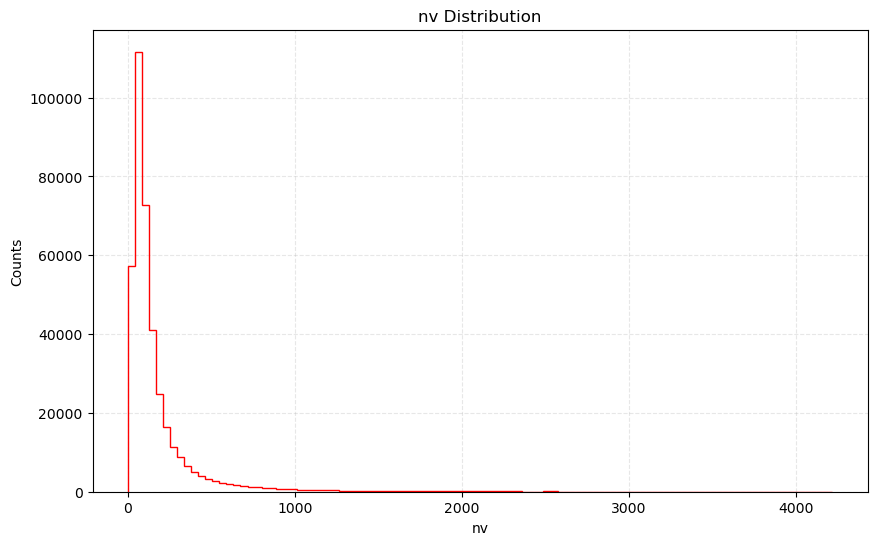

In [ ]:
# weight * energy 的分布
import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from concurrent.futures import ProcessPoolExecutor, as_completed

root_path = "/mnt/mydisk/WCDA_simulation/" # WCDA_simulation folder
n_workers = 32

# --- 收集所有 ROOT 文件 ---
file_paths = [os.path.join(root_path, f) for f in os.listdir(root_path) if f.endswith(".root")]
print(f"📁 共找到 {len(file_paths)} 个 ROOT 文件")
file_paths = random.sample(file_paths,100)

# --- 定义单文件提取函数 ---
def extract_data(path):
    try:
        with uproot.open(path) as file:
            if "t_eventout;1" not in file:
                return pd.DataFrame()
            tree = file["t_eventout;1"]
            branches = ["nv", "mc_energy", "mc_weight",'mc_pid']
            available = [b for b in branches if b in tree.keys()]
            if len(available) < 3:
                return pd.DataFrame()
            df = tree.arrays(branches, library="pd")
            df["file"] = os.path.basename(path)
            return df
    except Exception as e:
        print(f"❌ {os.path.basename(path)} 读取失败: {e}")
        return pd.DataFrame()

# --- 并行提取 ---
dfs = []
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    futures = {executor.submit(extract_data, p): p for p in file_paths}
    for i, future in enumerate(as_completed(futures)):
        path = futures[future]
        try:
            df = future.result()
            if not df.empty:
                dfs.append(df)
        except Exception as e:
            print(f"⚠️ 文件 {path} 处理出错: {e}")
        if (i+1) % 10 == 0:
            print(f"进度: {i+1}/{len(file_paths)} 个文件已完成")

# --- 合并结果 ---
df_all = pd.concat(dfs, ignore_index=True)
print(f"✅ 数据提取完成，共 {len(df_all)} 条记录，来自 {len(dfs)} 个文件")

# --- 计算能量加权 ---
df_all["weight_energy"] = df_all["mc_weight"] * df_all["mc_energy"]

# --- 绘图 ---
plt.figure(figsize=(10, 6))

plt.hist(df_all["nv"], bins=100, histtype="step", color="red")
# plt.xscale("log")
plt.xlabel("nv")
# plt.xscale("log")
plt.ylabel("Counts")
plt.title("nv Distribution")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


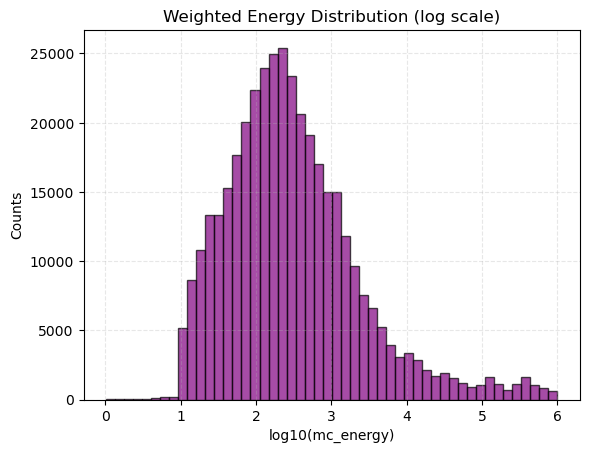

In [12]:
plt.hist(np.log10(df_all["mc_energy"]), bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel("log10(mc_energy)")
plt.ylabel("Counts")
# plt.yscale("log")
plt.title("Weighted Energy Distribution (log scale)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

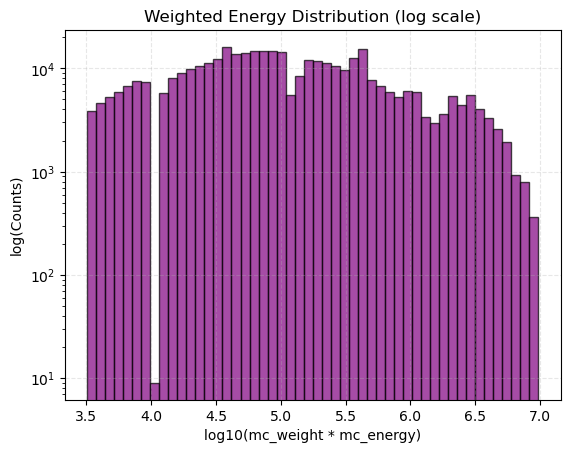

In [13]:
plt.hist(np.log10(df_all["weight_energy"]), bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel("log10(mc_weight * mc_energy)")
plt.ylabel("log(Counts)")
plt.yscale("log")
plt.title("Weighted Energy Distribution (log scale)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

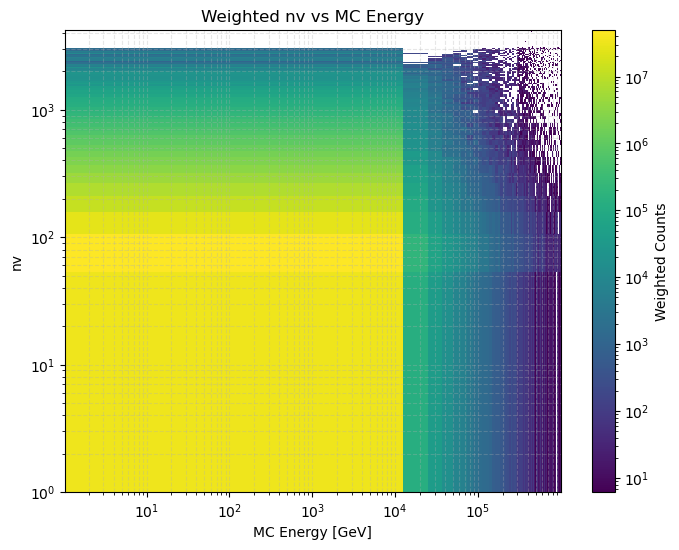

In [ ]:
# nv和energy的关系 ，热力图代表weight
plt.figure(figsize=(8,6))
plt.hist2d(
    df_all["mc_energy"],
    df_all["nv"],
    bins=[80, 80],
    weights=df_all["mc_weight"],
    norm='log'
)
plt.colorbar(label="Weighted Counts")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("MC Energy [GeV]")
plt.ylabel("nv")
plt.title("Weighted nv vs MC Energy")
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.show()


/tmp/ipykernel_1062705/2175551768.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nv = df_all.groupby(pd.cut(df_all["mc_energy"], bins))["nv"].mean()


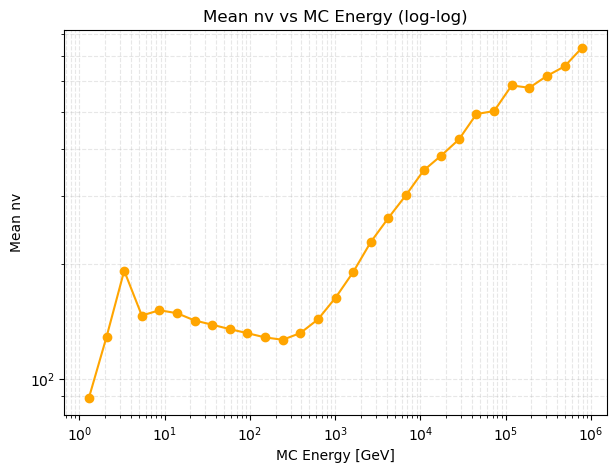

In [21]:
# 对数分箱
bins = np.logspace(np.log10(df_all["mc_energy"].min()), np.log10(df_all["mc_energy"].max()), 30)
bin_centers = np.sqrt(bins[:-1] * bins[1:])

mean_nv = df_all.groupby(pd.cut(df_all["mc_energy"], bins))["nv"].mean()

plt.figure(figsize=(7,5))
plt.plot(bin_centers, mean_nv, 'o-', color='orange')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("MC Energy [GeV]")
plt.ylabel("Mean nv")
plt.title("Mean nv vs MC Energy (log-log)")
plt.grid(True, which='both', ls='--', alpha=0.3)
plt.show()


### 进行分bin然后重新保存数据集

In [23]:
bins = [(60, 150), (150, 500), (500, 3000)]

for (low, high) in bins:
    count = ((df_all["nv"] >= low) & (df_all["nv"] < high)).sum()
    print(f"nv ∈ [{low}, {high}): {count} events")


nv ∈ [60, 150): 164320 events
nv ∈ [150, 500): 96230 events
nv ∈ [500, 3000): 22853 events


In [4]:
# 转换为 pandas DataFrame（前3条）
tree = file["t_eventout;1"]
df = tree.arrays(library="pd")
df.head(5)

,index,nv,nvx,vx,nvy,vy,nvq,vq,nvt,vt,nvnpe,vnpe,nvqsamp,vqsamp,theta,phi,xc,yc,mc_energy
0,0,155,155,"[135.17236328125, 104.4640121459961, 110.08170...",155,"[-43.923885345458984, -77.83198547363281, -19....",155,"[0.31011196970939636, 0.47632384300231934, 3.5...",155,"[8.420760154724121, -5.9090681076049805, 10.41...",155,"[0.5103868842124939, 0.7861276268959045, 5.548...",155,"[1.3213151693344116, 1.8068499565124512, 5.507...",0.387675,3.594235,6.119590,-66.226072,50.922184
1,2,297,297,"[221.1251983642578, 214.37168884277344, 220.37...",297,"[55.562870025634766, 37.15467071533203, 69.666...",297,"[0.1957385241985321, 0.5522672533988953, 0.146...",297,"[-3.341564178466797, -15.134008407592773, 7.98...",297,"[2.5275511741638184, 9.641826629638672, 2.0196...",297,"[0.0, 0.0, 1.316025972366333, 0.0, 1.199340462...",0.755883,2.282762,114.005202,-123.743844,4519.554688
2,6,373,373,"[14.159318923950195, 18.404693603515625, 32.61...",373,"[-73.9178237915039, -72.5468978881836, -93.953...",373,"[3.7637746334075928, 2.9684059619903564, 2.291...",373,"[-47.40794372558594, -37.648345947265625, 13.5...",373,"[6.139167785644531, 4.995551586151123, 3.70475...",373,"[4.890626430511475, 2.9220941066741943, 3.2934...",0.488770,4.434646,6.088194,-120.425763,1670.690918
3,8,326,326,"[177.51953125, 180.9456329345703, 157.37287902...",326,"[46.609352111816406, 77.90556335449219, 138.34...",326,"[2.683635711669922, 0.4565572440624237, 0.1381...",326,"[-23.70522689819336, 50.990943908691406, -19.8...",326,"[34.61933135986328, 8.79118537902832, 3.081781...",326,"[2.7952182292938232, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.713868,0.465588,-60.534656,-102.071716,103761.968750
4,9,167,167,"[215.7427215576172, 168.45248413085938, 184.36...",167,"[-76.16264343261719, -32.60722732543945, -13.5...",167,"[8.246577262878418, 0.3556147813796997, 0.5240...",167,"[-57.0481071472168, -9.235764503479004, -0.438...",167,"[119.123291015625, 7.40498685836792, 6.5066161...",167,"[9.339736938476562, 0.0, 1.128913402557373, 0....",0.180376,0.059892,-74.469192,67.318479,998.259888


📁 本次随机选取使用 100 个ROOT文件数据进行评估
GPU状态检查
CUDA可用: True
GPU数量: 4
GPU 0: Tesla V100-SXM2-16GB
  内存分配: 0.01 GB
  内存缓存: 4.47 GB
GPU 1: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 2: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
GPU 3: Tesla V100-SXM2-16GB
  内存分配: 0.00 GB
  内存缓存: 0.00 GB
当前设备: 0
CUDA版本: 12.4
🔹 /home/server/mydisk/WCDA_simulation/Egr000001847_01_n0010_eventout.root: 保留 690/3759 个事件 (vqsamp>0.5 & E>100)
🔹 /home/server/mydisk/WCDA_simulation/Egr000005817_01_n0010_eventout.root: 保留 739/3802 个事件 (vqsamp>0.5 & E>100)
🔹 /home/server/mydisk/WCDA_simulation/Egr000004019_01_n0010_eventout.root: 保留 713/3722 个事件 (vqsamp>0.5 & E>100)
🔹 /home/server/mydisk/WCDA_simulation/Egr000008601_01_n0010_eventout.root: 保留 714/3862 个事件 (vqsamp>0.5 & E>100)🔹 /home/server/mydisk/WCDA_simulation/Egr000004393_01_n0010_eventout.root: 保留 723/3872 个事件 (vqsamp>0.5 & E>100)

🔹 /home/server/mydisk/WCDA_simulation/Egr000000339_01_n0010_eventout.root: 保留 775/3881 个事件 (vqsamp>0.5 & E>100)🔹 /home/s

/tmp/ipykernel_3304392/3241128541.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)



=== 模型评估结果 ===
能量分辨率 (resolution): 0.5730
能量偏差 (bias): -0.0351
⚠️ 共有 64383 个事件预测落在 logE∈[2,3] 区间 (87.36% of total)
📦 随机选取 9318 个对照事件（覆盖整预处理的数据集,剔除异常数据）


提取异常事件信息: 100%|██████████| 64383/64383 [00:02<00:00, 30759.59it/s]


✅ 已保存异常事件详细信息到: /home/server/projects/energy_reconstruction/error_data_full_raw_1113.parquet


提取对照组事件信息: 100%|██████████| 9318/9318 [00:00<00:00, 29212.83it/s]


✅ 已保存对照组事件详细信息到: /home/server/projects/energy_reconstruction/comp_data_full_raw_1113.parquet
✅ Resolution 图像已保存到: /home/server/projects/energy_reconstruction/fig/resolution_20251118_212227.png


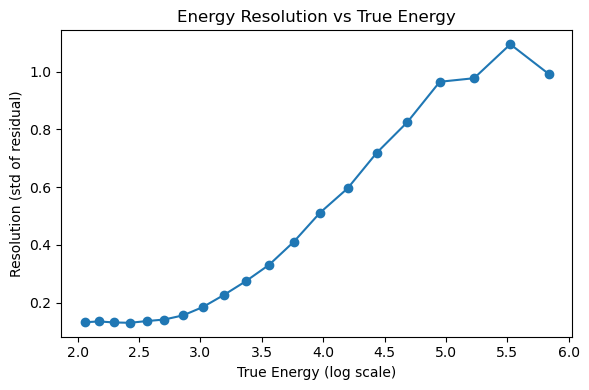

✅ LogE_pred vs logE_true 图像已保存到: /home/server/projects/energy_reconstruction/fig/pred_vs_true_20251118_212228.png


In [2]:
# 提取error_data 进行下一步分析
import sys
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
sys.path.append(os.path.abspath(".."))  # 添加上一级目录

from src import utils
from src.evaluate import evaluate_model
from src.ParticleDataset import ParticleDataset
from src.ParticleRegressor import ParticleNetRegressor
from src.utils import plot_resolution, plot_pred_vs_true
import random
# 主函数
def main():
    """
    使用已训练好的模型评估能量重建性能，
    并提取预测集中在 logE ∈ [2,3] 的事件保存到 pd.DataFrame。
    """
   
	 # ======== 读取数据文件夹 ========
    root_path = "/home/server/mydisk/WCDA_simulation/" # WCDA_simulation folder
    file_path = []
    for filename in os.listdir(root_path):
           full_path = os.path.join(root_path, filename)
           file_path.append(full_path)
    
	 # 随机提取100个进行评估
    test_files = file_path[-100:] # 500*20%
    print(f"📁 本次随机选取使用 {len(test_files)} 个ROOT文件数据进行评估")

	 # ======== 预处理条件 ========       
    processing_conditions = [
            {"name": "vx",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vy",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},  
            {"name": "vt",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0},
            {"name": "vq",        "subtract": 0,    "multiply": 1,    "min": -100000.0, "max": 100000.0}
        ]
    branches = [d["name"] for d in processing_conditions] # 提取name列表，便于后续读取相关的值 ，输入特征
    target_branch = ["mc_energy"] # 定义一个标签列表， 预测目标是能量
    processing_conditions = [
        {k: v for k, v in d.items() if k != "name"} # 删除掉name字段，只保留预处理操作字段
        for d in processing_conditions
    ]
    
   #  # ======== 先检查GPU状态 ========
    utils.check_gpu_status()
   
    # # ======== 只构建test数据集 ========
    batch_size = 256 
    test_dataset = ParticleDataset(
        root_files=test_files,
        branches=branches,
        target_branch=target_branch,
        processing_conditions=processing_conditions,
        max_points=256
    )
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # ======== 初始化模型 ========
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")
    model = ParticleNetRegressor(
        input_dims=2,  # vq, vt 两个特征
        conv_params=[(16, (64, 64, 64)), (16, (128, 128, 128)), (16, (256, 256, 256))],
        fc_params=[(256, 0.1)],
        use_fusion=True
    )
    
    # === 加载保存的模型参数 ===
    print("评估模型...")
    ckpt_path = "/home/server/projects/energy_reconstruction/best_model_full_1113.pt"
    checkpoint = torch.load(ckpt_path, map_location=device)
    # 兼容 DataParallel 保存的权重 在多GPU上训练，在单GPU上评估时遇到
    if any(k.startswith("module.") for k in checkpoint.keys()):
        checkpoint = {k.replace("module.", ""): v for k, v in checkpoint.items()}
        print("⚙️ 检测到 DataParallel 模型，已移除 'module.' 前缀")
    
    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()
    print(f"✅ 成功加载模型权重: {ckpt_path}")
    
	 # === 进行评估 ===
    predictions = []
    true_energies = []
    with torch.no_grad():
        for points, features, mask, logE_true in test_loader:
            points = points.to(device)
            features = features.to(device)
            mask = mask.to(device)
            logE_true = logE_true.to(device)

            # 模型预测 log(E)
            logE_pred = model(points, features, mask)


            predictions.extend(logE_pred.detach().cpu().numpy())
            true_energies.extend(logE_true.detach().cpu().numpy())

    predictions = np.array(predictions).flatten()
    true_energies = np.array(true_energies).flatten() # in log scale

    # ===== 异常值检查 =====
    if len(predictions) == 0 or np.any(np.isnan(predictions)) or np.any(np.isinf(predictions)):
        print("⚠️ 预测结果中存在异常值")
        return None, None

    # ===== 计算性能指标 =====
    rel_error = (predictions - true_energies)
    resolution = np.std(rel_error)
    bias = np.mean(rel_error)
    # r2 = r2_score(true_energies, predictions)

    print("\n=== 模型评估结果 ===")
    print(f"能量分辨率 (resolution): {resolution:.4f}")
    print(f"能量偏差 (bias): {bias:.4f}")
    # print(f"R² Score: {r2:.4f}")

    

    # ======== 提取错误预测事件 ========
    mask_error = (predictions > 2.0) & (predictions < 3.0)
    idx_error = np.where(mask_error)[0]
    print(f"⚠️ 共有 {len(idx_error)} 个事件预测落在 logE∈[2,3] 区间 ({len(idx_error)/len(predictions):.2%} of total)")
    
    # ======== 随机提取对照组事件数据 ========
    all_indices = np.arange(len(predictions))
    idx_comp = np.setdiff1d(all_indices, idx_error)
   #  mask_comp = ~mask_error
   #  idx_comp = np.random.choice(idx_rest, size=len(idx_error), replace=False)
   #  idx_comp = all_indices[mask_comp]
    print(f"📦 随机选取 {len(idx_comp)} 个对照事件（覆盖整预处理的数据集,剔除异常数据）")

    records_error = []
    # ---- 遍历这些事件，从 dataset.data 提取 raw 信息 ----
    for idx in tqdm(idx_error, desc="提取异常事件信息"):
       real_idx = test_dataset.indices[idx] # loader 第 idx 个样本对应真实事件索引
       rec = test_dataset.data[real_idx]
       raw = rec["raw"]
       proc = rec["processed"]
       
		 # 创建记录
       records_error.append({
           # ===== 基本事件信息 =====
           "file": rec["file"],
           "event_idx": rec["event_idx"],

           # ===== 原始信息 =====
           "nv": raw["n"],
           "vflag":raw["vflag"],
           "vidmc": raw["vidmc"],
           "vx":raw["vx"],
           "vy":raw["vy"],
           "vt":raw["vt"],
           "vnpe":raw["vnpe"],
           "vq":raw["vq"],
           "vqsamp":raw["vqsamp"],
           "xc": raw["xc"],
           "yc": raw["yc"],
           "theta": raw["theta"],
           "phi": raw["phi"],
           "chi2": raw["chi2"],
           "dcedge":raw["dcedge"],
           "dcedgepool":raw["dcedgepool"],
           "istationcore":raw["istationcore"],
           "ccindex":raw["ccindex"],
           "chi2":raw["chi2"],
           "rmds":raw["rmds"],
           "compactness": raw["compactness"],
           "pincness": raw["pincness"],
           "mc_weight":raw["mc_weight"],
           "mc_pid":raw["mc_pid"],
           "mc_energy":raw["mc_energy"],
           "mc_theta":raw["mc_theta"],
           "mc_phi":raw["mc_phi"],
           "mc_xc":raw["mc_xc"],
           "mc_yc":raw["mc_yc"],
           "mc_dangle":raw["mc_dangle"],
           "mc_dcore":raw["mc_dcore"],
           
			  "vx_len": len(raw["vx"]), #　vx的长度
           "vq_mean": float(np.mean(raw["vq"])),# vq的平均值
           "vt_mean": float(np.mean(raw["vt"])),# vt的平均值
           "vqsamp_nonzero": int(np.count_nonzero(raw["vqsamp"])),# vqsamp非零值的个数

           # ===== 模型相关 =====
           "logE_true": float(proc["log_energy"]),
           "logE_pred": float(predictions[idx]),
           "abs_err": float(predictions[idx] - proc["log_energy"]),
           "rel_ratio": float(predictions[idx] - proc["log_energy"]), # log(E_pred/E_true)

       })
    df_error = pd.DataFrame(records_error)
    save_path = "/home/server/projects/energy_reconstruction/error_data_full_raw_1113.parquet"
    df_error.to_parquet(save_path, index=False)
    print(f"✅ 已保存异常事件详细信息到: {save_path}")
    

    records_comp = []
    # ---- 遍历这些事件，从 dataset.data 提取 raw 信息 ----
    for idx in tqdm(idx_comp, desc="提取对照组事件信息"):
       real_idx = test_dataset.indices[idx] # loader 第 idx 个样本对应真实事件索引
       rec = test_dataset.data[real_idx]
       raw = rec["raw"]
       proc = rec["processed"]
       
		 # 创建记录
       records_comp.append({
           # ===== 基本事件信息 =====
           "file": rec["file"],
           "event_idx": rec["event_idx"],

           # ===== 原始信息 =====
           "nv": raw["n"],
           "vflag":raw["vflag"],
           "vidmc": raw["vidmc"],
           "vx":raw["vx"],
           "vy":raw["vy"],
           "vt":raw["vt"],
           "vnpe":raw["vnpe"],
           "vq":raw["vq"],
           "vqsamp":raw["vqsamp"],
           "xc": raw["xc"],
           "yc": raw["yc"],
           "theta": raw["theta"],
           "phi": raw["phi"],
           "chi2": raw["chi2"],
           "dcedge":raw["dcedge"],
           "dcedgepool":raw["dcedgepool"],
           "istationcore":raw["istationcore"],
           "ccindex":raw["ccindex"],
           "chi2":raw["chi2"],
           "rmds":raw["rmds"],
           "compactness": raw["compactness"],
           "pincness": raw["pincness"],
           "mc_weight":raw["mc_weight"],
           "mc_pid":raw["mc_pid"],
           "mc_energy":raw["mc_energy"],
           "mc_theta":raw["mc_theta"],
           "mc_phi":raw["mc_phi"],
           "mc_xc":raw["mc_xc"],
           "mc_yc":raw["mc_yc"],
           "mc_dangle":raw["mc_dangle"],
           "mc_dcore":raw["mc_dcore"],
           
			  "vx_len": len(raw["vx"]), #　vx的长度
           "vq_mean": float(np.mean(raw["vq"])),# vq的平均值
           "vt_mean": float(np.mean(raw["vt"])),# vt的平均值
           "vqsamp_nonzero": int(np.count_nonzero(raw["vqsamp"])),# vqsamp非零值的个数

           # ===== 模型相关 =====
           "logE_true": float(proc["log_energy"]),
           "logE_pred": float(predictions[idx]),
           "abs_err": float(predictions[idx] - proc["log_energy"]),
           "rel_ratio": float(predictions[idx] - proc["log_energy"]), # log(E_pred/E_true)

       })
    df_comp = pd.DataFrame(records_comp)
    save_path = "/home/server/projects/energy_reconstruction/comp_data_full_raw_1113.parquet"
    df_comp.to_parquet(save_path, index=False)
    print(f"✅ 已保存对照组事件详细信息到: {save_path}")

    return predictions, true_energies, df_error, df_comp
   

if __name__ == "__main__":

    pred, true, df_error, df_comp = main()  # log10(E)
        # ==== 画图 ====  
    plot_resolution(true, pred)
    plot_pred_vs_true(true, pred)


In [ ]:
# 接下来分析 df_error

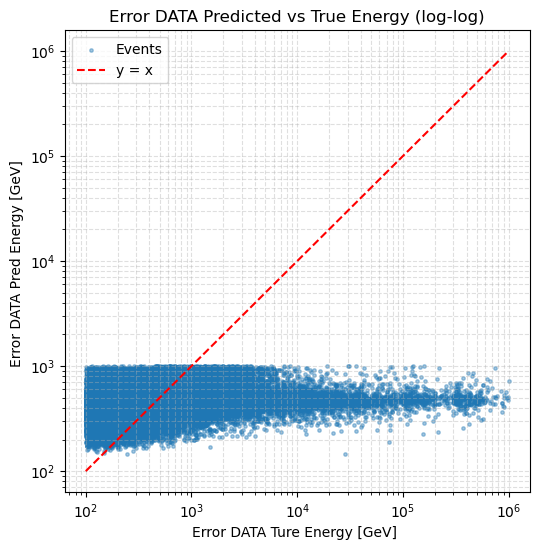

In [3]:
#　首先画出logE_true vs logE_pred
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))
plt.scatter(10 ** df_error["logE_true"], 10 ** df_error["logE_pred"], s=6, alpha=0.4,label="Events")
mn = min(10 ** df_error["logE_true"].min(), 10 ** df_error["logE_pred"].min())
mx = max(10 ** df_error["logE_true"].max(), 10 ** df_error["logE_pred"].max())
plt.plot([mn, mx], [mn, mx], 'r--', label='y = x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Error DATA Ture Energy [GeV] ')
plt.ylabel('Error DATA Pred Energy [GeV] ')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.title("Error DATA Predicted vs True Energy (log-log)")
plt.show()


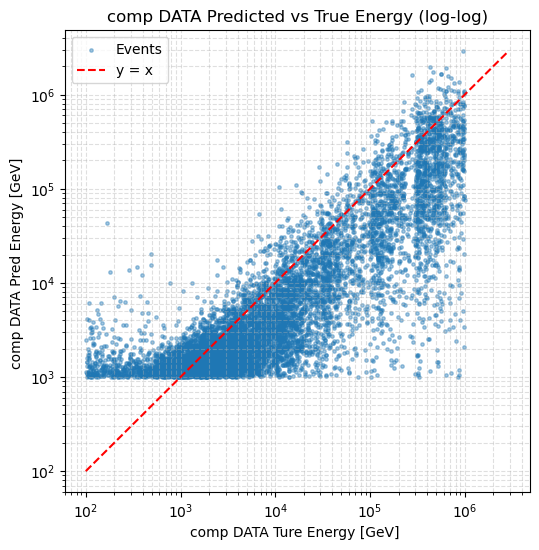

In [4]:
#　首先画出logE_true vs logE_pred
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))
plt.scatter(10 ** df_comp["logE_true"], 10 ** df_comp["logE_pred"], s=6, alpha=0.4,label="Events")
mn = min(10 ** df_comp["logE_true"].min(), 10 ** df_comp["logE_pred"].min())
mx = max(10 ** df_comp["logE_true"].max(), 10 ** df_comp["logE_pred"].max())
plt.plot([mn, mx], [mn, mx], 'r--', label='y = x')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('comp DATA Ture Energy [GeV] ')
plt.ylabel('comp DATA Pred Energy [GeV] ')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.title("comp DATA Predicted vs True Energy (log-log)")
plt.show()


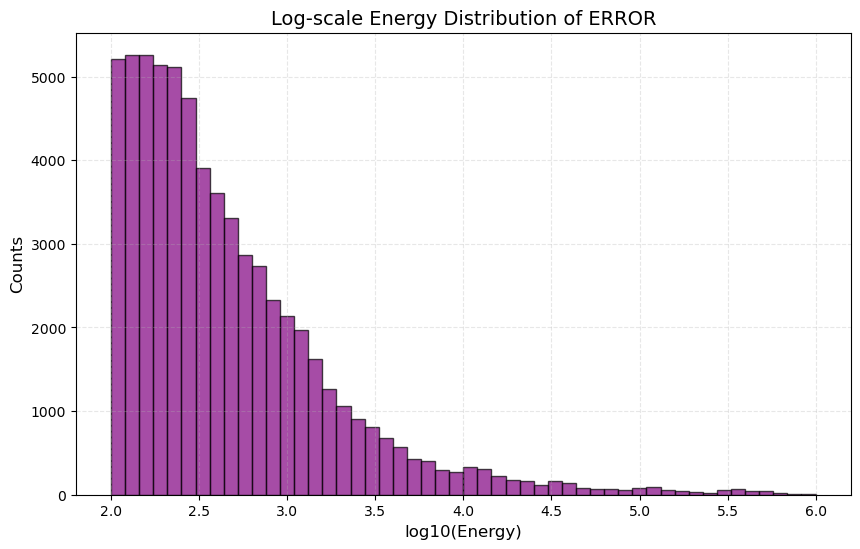

In [6]:
# 看看能量分布
plt.figure(figsize=(10, 6))
plt.hist(df_error["logE_true"], bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel("log10(Energy)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.title("Log-scale Energy Distribution of ERROR", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

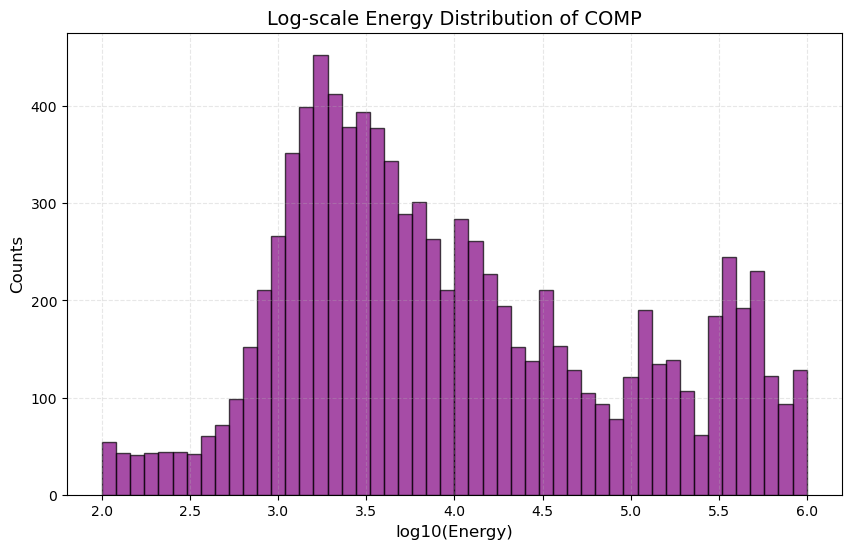

In [7]:
# 看看能量分布
plt.figure(figsize=(10, 6))
plt.hist(df_comp["logE_true"], bins=50, alpha=0.7, color='purple', edgecolor='black')
plt.xlabel("log10(Energy)", fontsize=12)
plt.ylabel("Counts", fontsize=12)
plt.title("Log-scale Energy Distribution of COMP", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


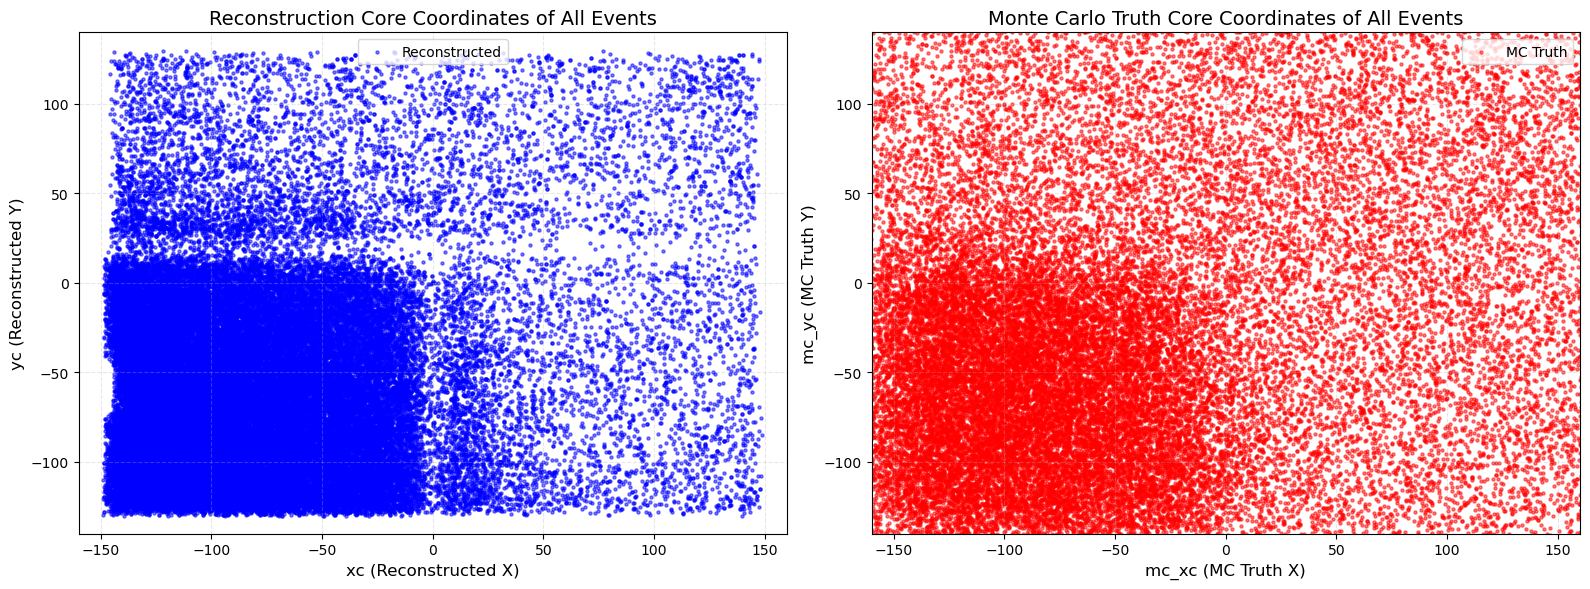

In [ ]:
# 画在WCDA水池上ERROR

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 设置固定的坐标范围
x_limits = [-160, 160]
y_limits = [-140, 140]

# (1) 重建坐标 xc vs yc
ax1.scatter(df_error["xc"], df_error["yc"], s=5, alpha=0.5, color='blue', label="Reconstructed")
ax1.set_xlabel("xc (Reconstructed X)", fontsize=12)
ax1.set_ylabel("yc (Reconstructed Y)", fontsize=12)
ax1.set_title("Reconstruction Core Coordinates of All Events", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend()
# 设置坐标范围
ax1.set_xlim(x_limits)
ax1.set_ylim(y_limits)

# (2) MC 真值坐标 mc_xc vs mc_yc
ax2.scatter(df_error["mc_xc"], df_error["mc_yc"], s=5, alpha=0.5, color='red', label="MC Truth")
ax2.set_xlabel("mc_xc (MC Truth X)", fontsize=12)
ax2.set_ylabel("mc_yc (MC Truth Y)", fontsize=12)
ax2.set_title("Monte Carlo Truth Core Coordinates of All Events", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend()
# 设置坐标范围
ax2.set_xlim(x_limits)
ax2.set_ylim(y_limits)

plt.tight_layout()
plt.show()

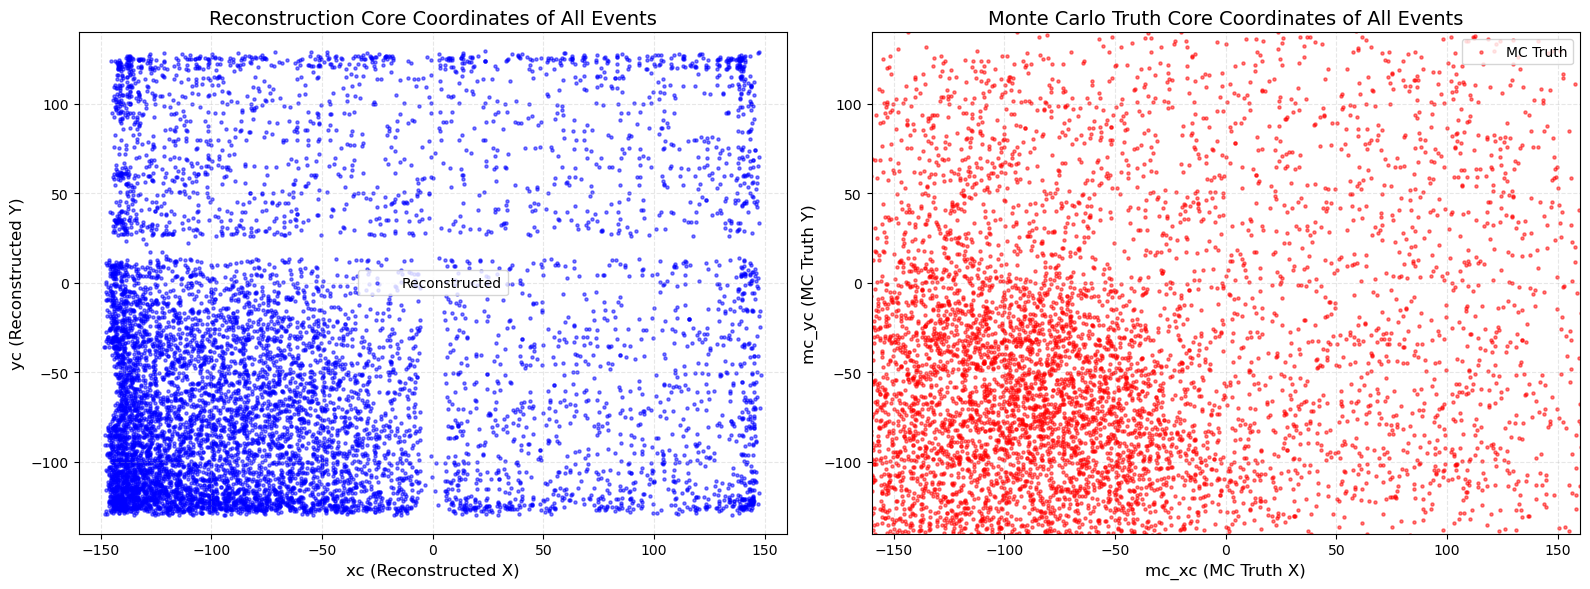

In [9]:
# 画在WCDA水池上COMP

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 设置固定的坐标范围
x_limits = [-160, 160]
y_limits = [-140, 140]

# (1) 重建坐标 xc vs yc
ax1.scatter(df_comp["xc"], df_comp["yc"], s=5, alpha=0.5, color='blue', label="Reconstructed")
ax1.set_xlabel("xc (Reconstructed X)", fontsize=12)
ax1.set_ylabel("yc (Reconstructed Y)", fontsize=12)
ax1.set_title("Reconstruction Core Coordinates of All Events", fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend()
# 设置坐标范围
ax1.set_xlim(x_limits)
ax1.set_ylim(y_limits)

# (2) MC 真值坐标 mc_xc vs mc_yc
ax2.scatter(df_comp["mc_xc"], df_comp["mc_yc"], s=5, alpha=0.5, color='red', label="MC Truth")
ax2.set_xlabel("mc_xc (MC Truth X)", fontsize=12)
ax2.set_ylabel("mc_yc (MC Truth Y)", fontsize=12)
ax2.set_title("Monte Carlo Truth Core Coordinates of All Events", fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend()
# 设置坐标范围
ax2.set_xlim(x_limits)
ax2.set_ylim(y_limits)

plt.tight_layout()
plt.show()

In [ ]:
#　为什么这些df_error 集中在一号水池？？？ 筛选掉一号水池的数据重新进行训练？？？
#  集中在1号水池的原因应该是vqsamp和E>100GeV的条件有关

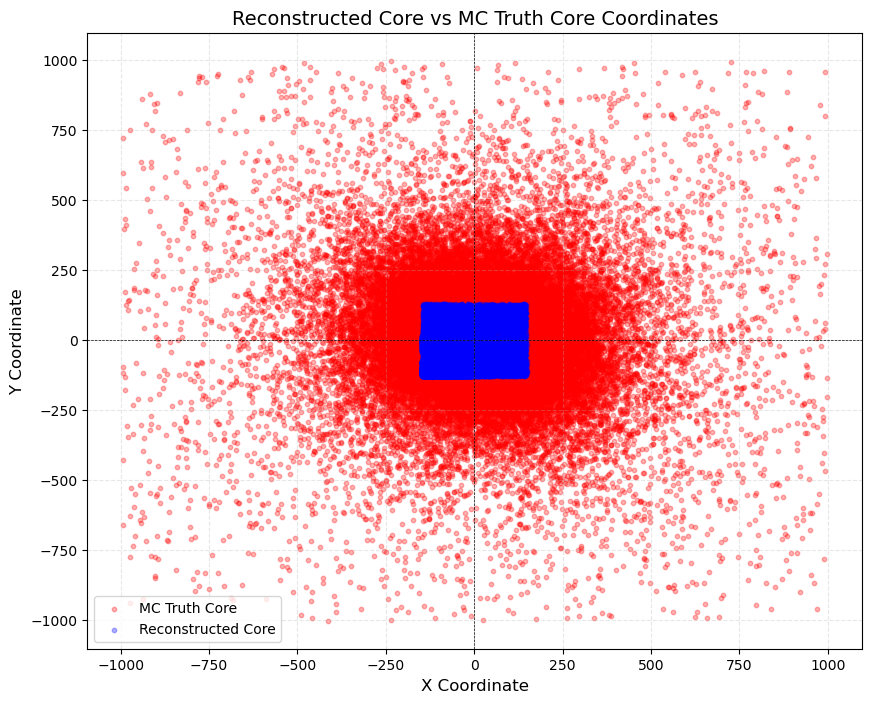

In [10]:
plt.figure(figsize=(10, 8))
plt.scatter(df_error["mc_xc"], df_error["mc_yc"], s=10, alpha=0.3, color='red', label="MC Truth Core")
plt.scatter(df_error["xc"], df_error["yc"], s=10, alpha=0.3, color='blue', label="Reconstructed Core")


plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)

plt.xlabel("X Coordinate", fontsize=12)
plt.ylabel("Y Coordinate", fontsize=12)
plt.title("Reconstructed Core vs MC Truth Core Coordinates", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


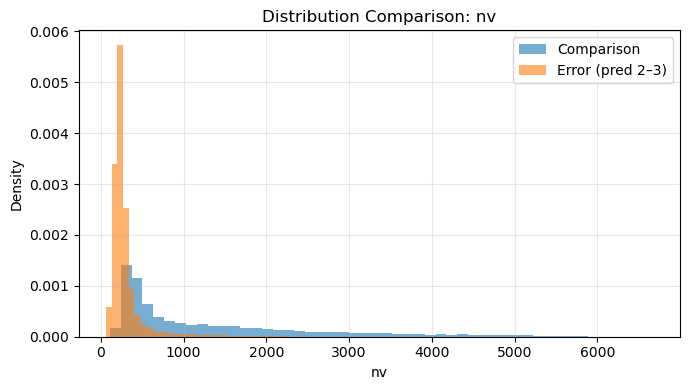

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 加载你的异常事件数据
df_error = pd.read_parquet("/home/server/projects/energy_reconstruction/error_data_full_raw_1113.parquet")

# 加载一批正常事件（你可以从 training dataset 抽取）
df_comp = pd.read_parquet("/home/server/projects/energy_reconstruction/comp_data_full_raw_1113.parquet")

# 只保留两边都存在的关键字段
common_cols = list(set(df_error.columns) & set(df_comp.columns))
df_error = df_error[common_cols]
df_comp = df_comp[common_cols]

def compare_distribution(feature, bins=50, log=False):
    plt.figure(figsize=(7,4))
    plt.hist(df_comp[feature], bins=bins, alpha=0.6, label="Comparison", density=True)
    plt.hist(df_error[feature], bins=bins, alpha=0.6, label="Error (pred 2–3)", density=True)
    plt.legend()
    
    if log:
         plt.xscale("log")
         plt.xlabel(feature + "(log scale)")
    else:
         plt.xlabel(feature)
         
    plt.ylabel("Density")
    plt.title(f"Distribution Comparison: {feature}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ========= 1. Hits 数量 =========
compare_distribution("nv")



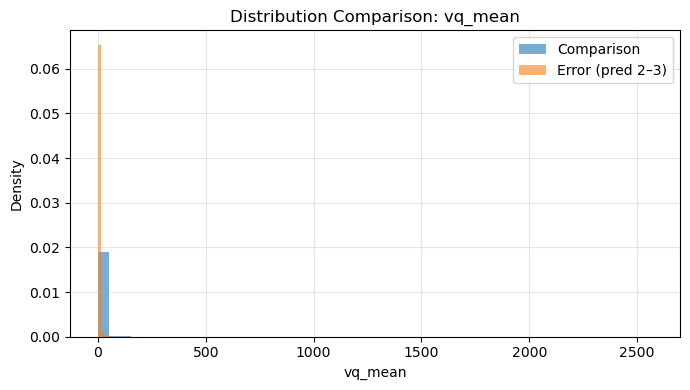

In [10]:
# ========= 2. 电荷强度 =========
compare_distribution("vq_mean")


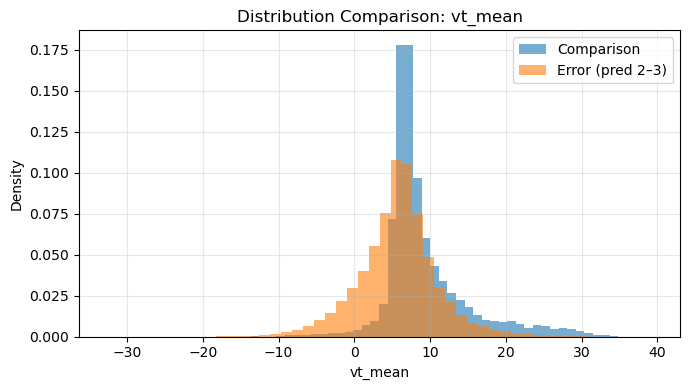

In [11]:
# ========= 3. 时序特征 =========
compare_distribution("vt_mean")


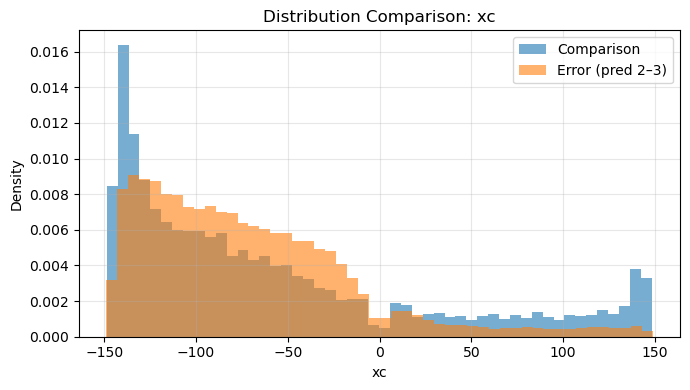

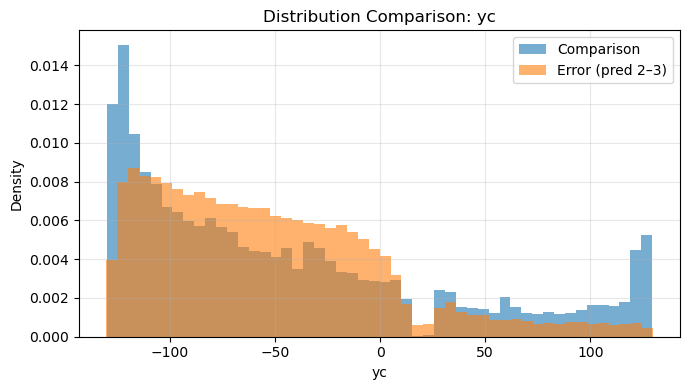

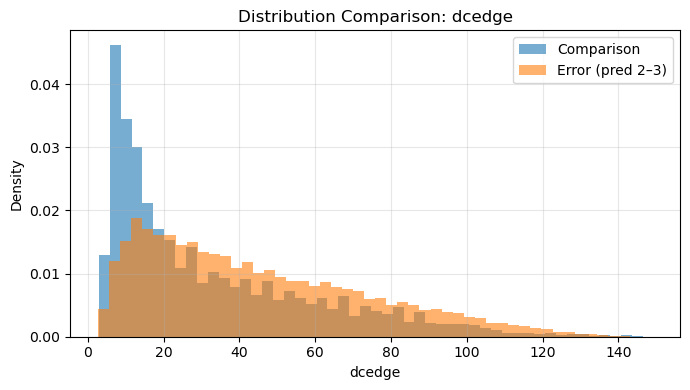

In [12]:

# ========= 4. 空间位置 =========
compare_distribution("xc")
compare_distribution("yc")
compare_distribution("dcedge")




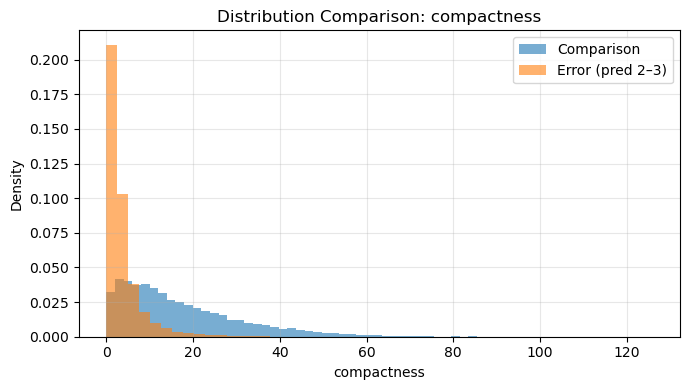

In [13]:
# ========= 5. shower shapes =========
compare_distribution("compactness")



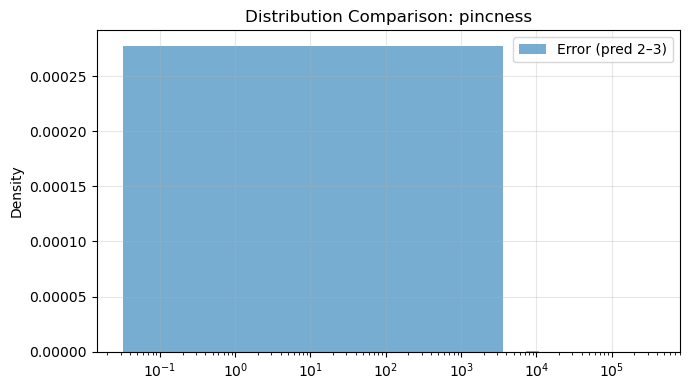

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df_comp["pincness"], bins=100, alpha=0.6, label="Comparison", density=True)
plt.hist(df_error["pincness"], bins=100, alpha=0.6, label="Error (pred 2–3)", density=True)
plt.legend()
plt.xscale('log') #对数分bin对数画图
plt.ylabel("Density")
plt.title("Distribution Comparison: pincness")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

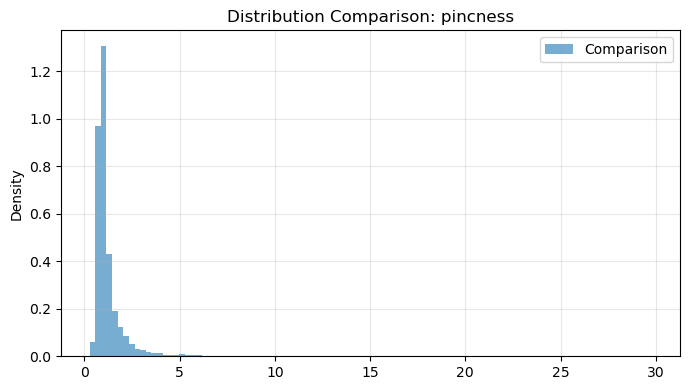

ERROR分布：
count     64383.000000
mean         46.274848
std        1780.882615
min           0.032778
25%           1.616113
50%           2.593063
75%           4.056228
max      358963.875000
Name: pincness, dtype: float64
COMP分布：
count    9318.000000
mean        1.235556
std         0.973436
min         0.270004
25%         0.833137
50%         0.974284
75%         1.260662
max        29.791767
Name: pincness, dtype: float64


In [26]:
plt.figure(figsize=(7,4))
plt.hist(df_comp["pincness"], bins=100, alpha=0.6, label="Comparison", density=True)
# plt.hist(df_error["pincness"], bins=bins, alpha=0.6, label="Error (pred 2–3)", density=True)
plt.legend()

plt.ylabel("Density")
plt.title("Distribution Comparison: pincness")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("ERROR分布：")
print(df_error["pincness"].describe())
print("COMP分布：")
print(df_comp["pincness"].describe())



In [ ]:
# comparison的pincess要远小于error数据的，error的数据很小，分布范围很宽，被平均分布在很长的能量区间里了。
# pincess反应了能量沉积，越小能量越集中。comparison普遍都比较小，也没有很大的离群值
# 考虑通过pincess筛选出一些事例

In [31]:
print("ERROR分布：")
print(df_error["chi2"].describe())
print("COMP分布：")
print(df_comp["chi2"].describe())

ERROR分布：
count    6.438300e+04
mean     3.572372e+16
std      1.889749e+18
min     -6.661338e-16
25%      1.385450e+01
50%      2.643246e+01
75%      5.410557e+01
max      1.000000e+20
Name: chi2, dtype: float64
COMP分布：
count      9318.000000
mean        659.264323
std       13259.684770
min           0.067883
25%          82.042550
50%         193.091455
75%         361.638709
max      592132.800853
Name: chi2, dtype: float64


In [ ]:
# ERROR数据里chi2的离群分布也特别大，存在一些极端的值

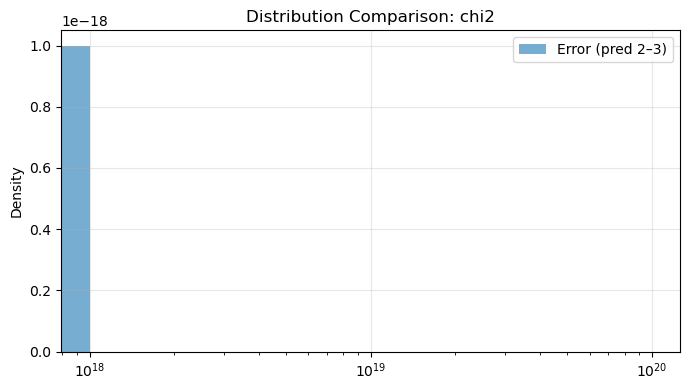

In [34]:
plt.figure(figsize=(7,4))
# plt.hist(df_comp["pincness"], bins=100, alpha=0.6, label="Comparison", density=True)
plt.hist(df_error["chi2"], bins=100, alpha=0.6, label="Error (pred 2–3)", density=True)
plt.legend()
plt.xscale('log')
plt.ylabel("Density")
plt.title("Distribution Comparison: chi2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

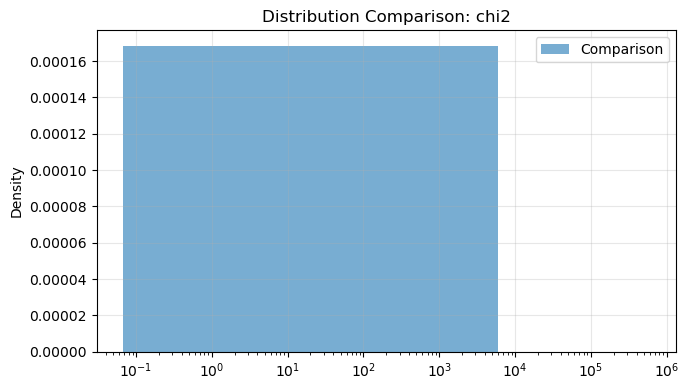

In [36]:
plt.figure(figsize=(7,4))
plt.hist(df_comp["chi2"], bins=100, alpha=0.6, label="Comparison", density=True)
# plt.hist(df_error["pincness"], bins=bins, alpha=0.6, label="Error (pred 2–3)", density=True)
plt.legend()
plt.xscale('log')
plt.ylabel("Density")
plt.title("Distribution Comparison: chi2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

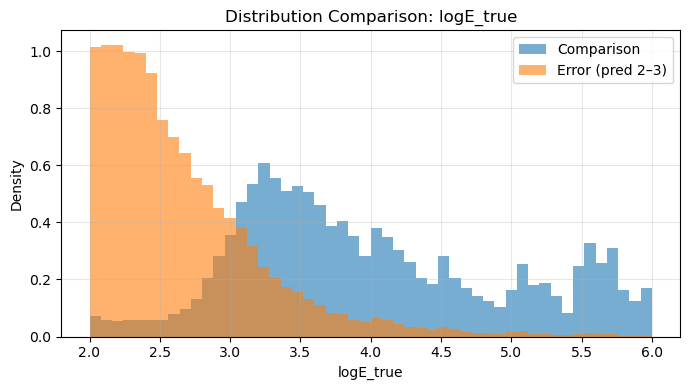

In [18]:
# ========= 6. 能量分布 =========
compare_distribution("logE_true")

